# Sistem Rekomendasi

# Pengumpulan Data

In [125]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import random
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

df_usda = pd.read_excel("usda.xlsx")



# EDA Sebelum Pre-Processing

Struktur Dataset Sebelum Pre-Processing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4993 entries, 0 to 4992
Data columns (total 47 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FoodID            4993 non-null   int64  
 1   FoodCategory      4993 non-null   object 
 2   FoodName          4993 non-null   object 
 3   Air               4992 non-null   float64
 4   Energi            4958 non-null   float64
 5   Protein           4832 non-null   float64
 6   Lemak             4723 non-null   float64
 7   Abu               4647 non-null   float64
 8   Karbohidrat       4298 non-null   float64
 9   Serat             3197 non-null   float64
 10  GulaTotal         3235 non-null   float64
 11  Kalsium           4583 non-null   float64
 12  Besi              4773 non-null   float64
 13  Magnesium         4509 non-null   float64
 14  Fosfor            4539 non-null   float64
 15  Kalium            4755 non-null   float64
 16  N

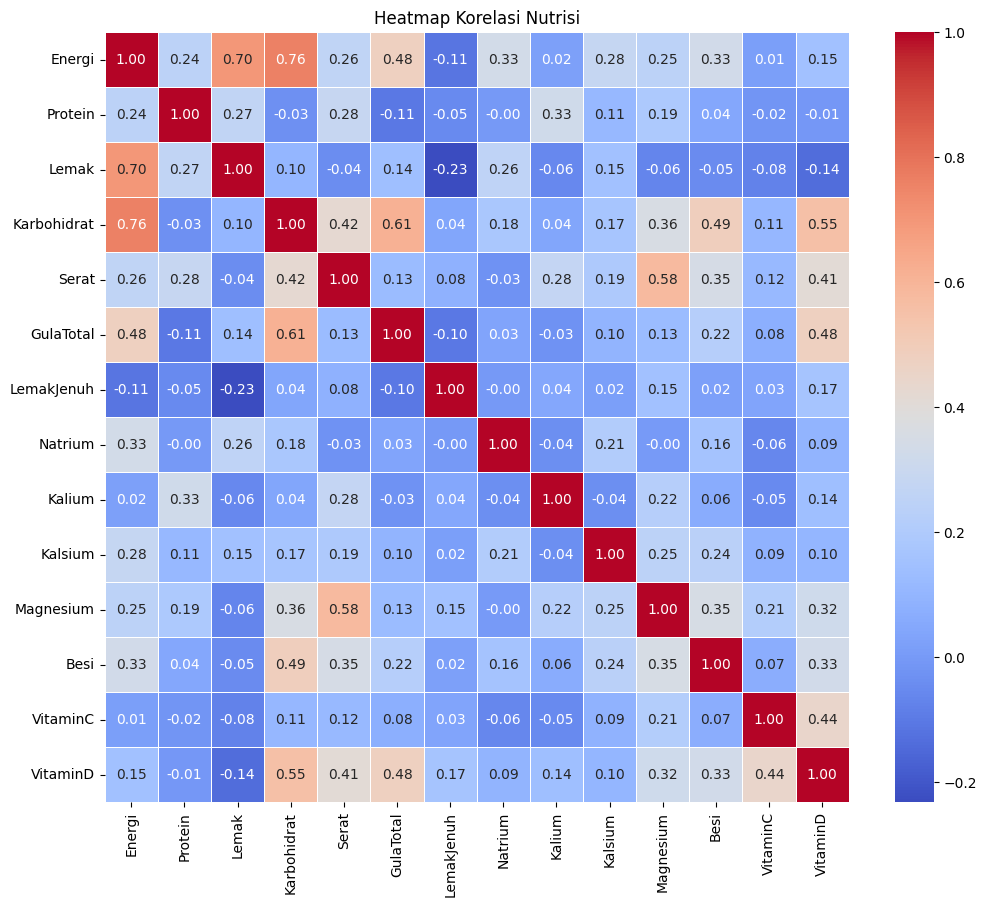

In [126]:
# Melihat struktur dataset
print("Struktur Dataset Sebelum Pre-Processing:")
print(df_usda.info())

# Melihat jumlah data dan kolom
print("\nBentuk Dataset Sebelum Pre-Processing:", df_usda.shape)

# Melihat beberapa data awal
print("\nSample Data Sebelum Pre-Processing:")
print(df_usda.head())

# Melihat statistik deskriptif
print("\nStatistik Deskriptif Sebelum Pre-Processing:")
print(df_usda.describe())

# Melihat nilai yang hilang
print("\nJumlah Nilai yang Hilang per Kolom Sebelum Pre-Processing:")
print(df_usda.isnull().sum())

# Melihat duplikat data
print("\nJumlah Duplikat Data Sebelum Pre-Processing:",df_usda.duplicated().sum())

# Melihat duplikat berdasarkan FoodID
print("\nJumlah Duplikat Berdasarkan FoodID Sebelum Pre-Processing:", df_usda.duplicated(subset=['FoodID']).sum())

# Melihat duplikat berdasarkan FoodName
print("\nJumlah Duplikat Berdasarkan FoodName Sebelum Pre-Processing:", df_usda.duplicated(subset=['FoodName']).sum())

print("Data duplikat berdasarkan 'FoodName':")
print(df_usda[df_usda.duplicated(subset=['FoodName'], keep=False)])

# Melihat distribusi kategori makanan
print("\nDistribusi Kategori Makanan Sebelum Pre-Processing:")
print(df_usda['FoodCategory'].value_counts())

# Melihat heatmap korelasi nutrisi
num_col = [
    'Energi', 'Protein', 'Lemak', 'Karbohidrat', 'Serat',
    'GulaTotal', 'LemakJenuh',
    'Natrium', 'Kalium', 'Kalsium', 'Magnesium',
    'Besi', 'VitaminC', 'VitaminD']
correlation_matrix = df_usda[num_col].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Nutrisi')
plt.show()

# Pre-Processing Data

In [127]:
def preprocess_data(df):
    # Memilih makanan relevan
    df_clean = df[~df['FoodName'].str.contains( 'mentah|tidak siap|alkohol|babi|leavening|baking soda|baking powder|'
                                                'ragi|bir|keras|pengganti krim', case=False, na=False )].copy()
    df_clean = df_clean[df_clean['FoodCategory'] != 'Babi']

    # 2. Membuat kolom baru 'FoodGroup' berdasarkan 'FoodCategory'

    food_group_mapping = {
        'Daging dan Sosis': 'Makanan Utama',
        'Daging Merah dan Hasil Buruan': 'Makanan Utama',
        'Ikan dan Kerang': 'Makanan Utama',
        'Sereal dan Pasta': 'Makanan Utama',
        'Unggas': 'Makanan Utama',
        'Keju, Susu, dan Telur': 'Makanan Pendamping',
        'Makanan Pembuka dan Lauk': 'Makanan Pendamping',
        'Produk Panggang': 'Makanan Pendamping',
        'Sayuran': 'Makanan Pendamping',
        'Sup dan Kaldu': 'Makanan Pendamping',
        'Buah dan Jus': 'Minuman dan Buah',
        'Minuman': 'Minuman dan Buah'
    }
    df_clean['FoodGroup'] = df_clean['FoodCategory'].map(food_group_mapping)

    # Memindahkan kolom FoodGroup agar berada sebelum FoodName
    cols = df_clean.columns.tolist()
    food_name_idx = cols.index('FoodName')

    # Hapus FoodGroup dari posisi aslinya (jika sudah ada, yang seharusnya tidak jika baru dibuat)
    if 'FoodGroup' in cols:
        cols.remove('FoodGroup')
    # Masukkan FoodGroup pada posisi sebelum FoodName
    cols.insert(food_name_idx, 'FoodGroup')
    df_clean = df_clean[cols]

    # Mengisi nilai kosong dengan 0
    df_clean.fillna(0, inplace=True)

    # Menghapus duplikat berdasarkan FoodName
    df_clean = df_clean.drop_duplicates(subset=['FoodName'])

    # Memilih kolom yang akan digunakan
    selected_columns = [
            'FoodID', 'FoodCategory', 'FoodGroup', 'FoodName',
            'Energi', 'Protein', 'Lemak', 'Karbohidrat', 'Serat',
            'GulaTotal', 'LemakJenuh',
            'Natrium', 'Kalium', 'Kalsium', 'Magnesium',
            'Besi', 'VitaminC', 'VitaminD'
    ]
    df_clean = df_clean[selected_columns]

    # Simpan salinan data asli sebelum normalisasi
    df_original = df_clean.copy()

    # Normalisasi data nutrisi
    non_numeric_cols = ['FoodID', 'FoodCategory', 'FoodGroup', 'FoodName']
    numeric_cols = [col for col in df_clean.columns if col not in non_numeric_cols]
    scaler = MinMaxScaler()
    df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

    return df_clean, scaler, df_original, numeric_cols

df_preprocessed, scaler, df_original, nutrient_cols = preprocess_data(df_usda)

# EDA Setelah Pre-Processing

Struktur Dataset Setelah Pre-Processing:
<class 'pandas.core.frame.DataFrame'>
Index: 4272 entries, 256 to 4992
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FoodID        4272 non-null   int64  
 1   FoodCategory  4272 non-null   object 
 2   FoodGroup     4272 non-null   object 
 3   FoodName      4272 non-null   object 
 4   Energi        4272 non-null   float64
 5   Protein       4272 non-null   float64
 6   Lemak         4272 non-null   float64
 7   Karbohidrat   4272 non-null   float64
 8   Serat         4272 non-null   float64
 9   GulaTotal     4272 non-null   float64
 10  LemakJenuh    4272 non-null   float64
 11  Natrium       4272 non-null   float64
 12  Kalium        4272 non-null   float64
 13  Kalsium       4272 non-null   float64
 14  Magnesium     4272 non-null   float64
 15  Besi          4272 non-null   float64
 16  VitaminC      4272 non-null   float64
 17  VitaminD      4272 non-null   flo

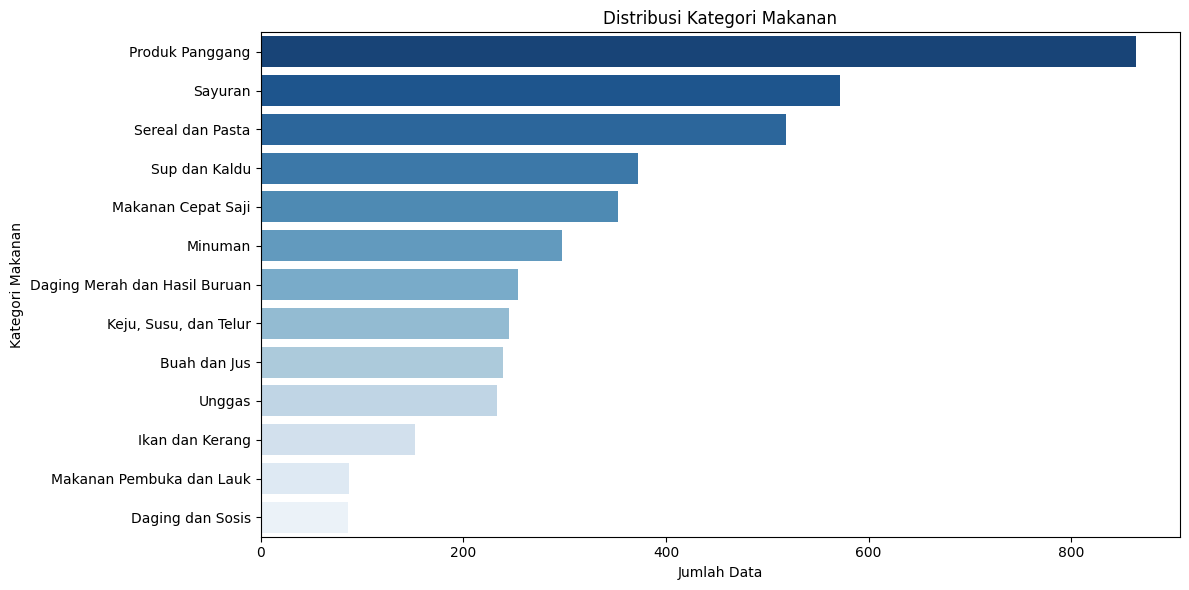

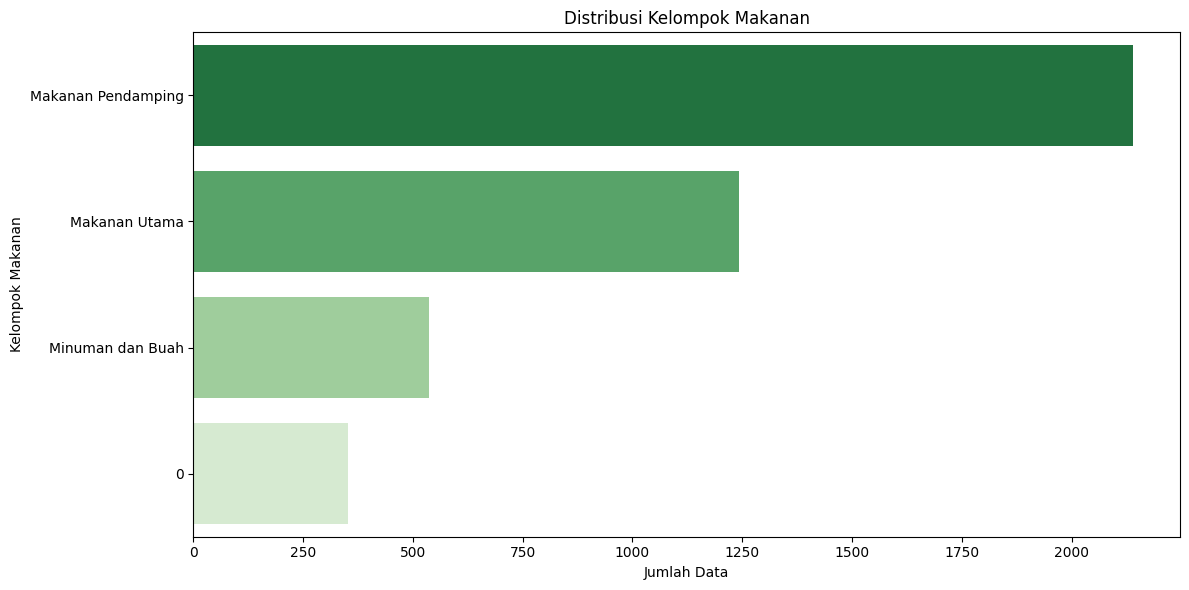

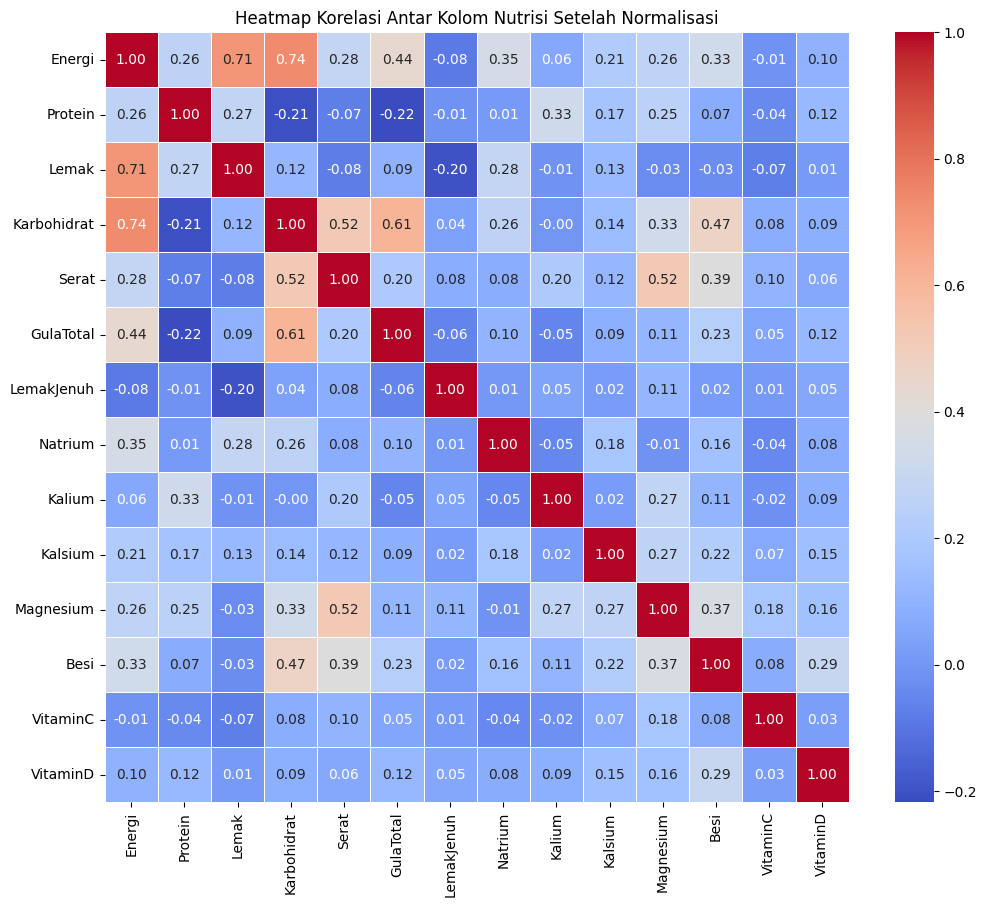

In [128]:
# Melihat struktur dataset setelah pre-processing
print("Struktur Dataset Setelah Pre-Processing:")
print(df_preprocessed.info())

# Melihat jumlah data dan kolom setelah pre-processing
print("\nBentuk Dataset Setelah Pre-Processing:", df_preprocessed.shape)

# Melihat beberapa data awal setelah pre-processing
print("\nSample Data Setelah Pre-Processing:")
print(df_preprocessed.head())

# Melihat statistik deskriptif setelah pre-processing
print("\nStatistik Deskriptif Setelah Pre-Processing:")
print(df_preprocessed.describe())

# Melihat statistik deskriptif setelah normalisasi
print("\nStatistik Deskriptif Setelah Normalisasi:")
print(df_preprocessed[nutrient_cols].describe())

# Melihat nilai yang hilang setelah pre-processing
print("\nJumlah Nilai yang Hilang per kolom Setelah Pre-Processing:")
print(df_preprocessed.isnull().sum())

# Melihat duplikat data setelah pre-processing
print("\nJumlah Duplikat Data Setelah Pre-Processing:",df_preprocessed.duplicated().sum())

# Melihat duplikat berdasarkan FoodID setelah pre-processing
print("\nJumlah Duplikat Berdasarkan FoodID Setelah Pre-Processing:", df_preprocessed.duplicated(subset=['FoodID']).sum())

# Melihat duplikat berdasarkan FoodName setelah pre-processing
print("\nJumlah Duplikat Berdasarkan FoodName Setelah Pre-Processing:", df_preprocessed.duplicated(subset=['FoodName']).sum())

# Melihat distribusi kategori makanan setelah pre-processing
print("\nDistribusi Kategori Makanan:")
print(df_preprocessed['FoodCategory'].value_counts())

# Melihat distribusi kelompok makanan setelah pre-processing
print("\nDistribusi Kelompok Makanan:")
print(df_preprocessed['FoodGroup'].value_counts())

# Visualisasi distribusi Kategori Makanan
plt.figure(figsize=(12, 6))
sns.countplot(data=df_preprocessed, y='FoodCategory', order=df_preprocessed['FoodCategory'].value_counts().index, palette='Blues_r')
plt.title('Distribusi Kategori Makanan')
plt.xlabel('Jumlah Data')
plt.ylabel('Kategori Makanan')
plt.tight_layout()
plt.savefig('food_category_distribution.png') # Simpan plot sebagai file gambar
plt.show()

# Visualisasi distribusi Kelompok Makanan
plt.figure(figsize=(12, 6))
sns.countplot(data=df_preprocessed, y='FoodGroup', order=df_preprocessed['FoodGroup'].value_counts().index, palette='Greens_r')
plt.title('Distribusi Kelompok Makanan')
plt.xlabel('Jumlah Data')
plt.ylabel('Kelompok Makanan')
plt.tight_layout()
plt.savefig('food_group_distribution.png')
plt.show()

# Melihat heatmap korelasi nutrisi setelah pre-processing
correlation_matrix = df_preprocessed[nutrient_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antar Kolom Nutrisi Setelah Normalisasi')
plt.show()

# Pengolahan Data Pengguna

In [129]:
def calculate_bmi(weight, height):
    height_m = height / 100
    bmi = weight / (height_m ** 2)
    return bmi


def get_bmi_category(bmi):
    if bmi < 18.5:
        return "Berat Badan Kurang (Underweight)"
    elif 18.5 <= bmi < 25:
        return "Berat Badan Normal"
    elif 25 <= bmi < 30:
        return "Berat Badan Berlebih (Overweight)"
    elif 30 <= bmi < 35:
        return "Obesitas I"
    elif 35 <= bmi < 40:
        return "Obesitas II"
    else:
        return "Obesitas III"


def calculate_energy_needs(gender, age, height, weight, activity_level):
    # Hitung BMR menggunakan Mifflin-St Jeor
    if gender.lower() == 'laki-laki':
        bmr = (10 * weight) + (6.25 * height) - (5 * age) + 5
    else:
        bmr = (10 * weight) + (6.25 * height) - (5 * age) - 161

    # Tentukan faktor aktivitas
    activity_factors = {
        "sedentary": 1.2,
        "lightly active": 1.375,
        "moderately active": 1.55,
        "very active": 1.725,
        "extra active": 1.9
    }

    return bmr * activity_factors[activity_level]


def get_age_category(age):
    if 10 <= age <= 18:
        return "remaja"
    elif 19 <= age <= 64:
        return "dewasa"
    else:
        return "lansia"

def calculate_weight_loss_plan(current_weight, target_weight, duration_months, energy_needs):
    total_loss = current_weight - target_weight       # kg
    total_deficit = total_loss * 7700                 # kkal
    duration_days = duration_months * 30
    daily_deficit = total_deficit / duration_days     # kkal/hari
    adjusted_energy = energy_needs - daily_deficit    # target kalori harian

    return {
        'total_loss_target': total_loss,
        'total_deficit_needed': total_deficit,
        'daily_deficit': daily_deficit,
        'adjusted_energy': adjusted_energy
    }

def validate_weight_loss_plan(current_weight, target_weight, duration_months):
    MAX_MONTHLY_LOSS = 4  # Batas maksimal penurunan berat badan per bulan (kg)

    warnings  = []
    suggestion = None

    # Validasi target harus lebih rendah dari berat saat ini
    if target_weight >= current_weight:
        warnings.append("Target berat badan harus lebih rendah.")
        return False, warnings, suggestion

    total_loss   = current_weight - target_weight
    monthly_loss = total_loss / duration_months

    # Cek batas aman 
    if monthly_loss > MAX_MONTHLY_LOSS:
        warnings.append("Target terlalu agresif.")

        # Hitung durasi minimum yang aman berdasarkan batas laju penurunan
        months_based_on_speed = total_loss / MAX_MONTHLY_LOSS

        # Bulatkan ke atas ke setengah bulan terdekat (misal 6.3 → 6.5)
        safe_duration_rounded = math.ceil(months_based_on_speed * 2) / 2

        suggestion = f"Untuk menurunkan {total_loss} kg dengan aman, disarankan durasi minimal selama {safe_duration_rounded} bulan."

    return True, warnings, suggestion

def get_nutrition_requirements(gender, age, adjusted_energy):
    age_category = get_age_category(age)
    idx = 0

    # Remaja laki-laki (10-18 tahun)
    if gender.lower() == 'laki-laki' and age_category == 'remaja':
        if 10 <= age <= 12: idx = 0
        elif 13 <= age <= 15: idx = 1
        elif 16 <= age <= 18: idx = 2

    # Dewasa laki-laki (19-64 tahun)
    elif gender.lower() == 'laki-laki' and age_category == 'dewasa':
        if 19 <= age <= 29: idx = 3
        elif 30 <= age <= 49: idx = 4
        elif 50 <= age <= 64: idx = 5

    # Lansia laki-laki (>64 tahun)
    elif gender.lower() == 'laki-laki' and age_category == 'lansia':
        if 65 <= age <= 80: idx = 6
        else: idx = 7

    # Remaja perempuan (10-18 tahun)
    elif gender.lower() == 'perempuan' and age_category == 'remaja':
        if 10 <= age <= 12: idx = 8
        elif 13 <= age <= 15: idx = 9
        elif 16 <= age <= 18: idx = 10

    # Dewasa perempuan (19-64 tahun)
    elif gender.lower() == 'perempuan' and age_category == 'dewasa':
        if 19 <= age <= 29: idx = 11
        elif 30 <= age <= 49: idx = 12
        elif 50 <= age <= 64: idx = 13

    # Lansia perempuan (>64 tahun)
    elif gender.lower() == 'perempuan' and age_category == 'lansia':
        if 65 <= age <= 80: idx = 14
        else: idx = 15

    nutrition_req = {
    'Energi'     : adjusted_energy,
    'Protein'    : (25 * adjusted_energy / 100) / 4,
    'Lemak'      : (25 * adjusted_energy / 100) / 9,
    'Karbohidrat': (50 * adjusted_energy / 100) / 4,
    'Serat'      : [28, 34, 37, 37, 36, 30, 25, 22, 27, 29, 29, 32, 30, 25, 22, 20][idx],
    'Natrium'    : [1300, 1500, 1700, 1500, 1500, 1300, 1100, 1000, 1400, 1500, 1600, 1500, 1500, 1400, 1200, 1000][idx],
    'Kalium'     : [3900, 4800, 5300, 4700, 4700, 4700, 4700, 4700, 4400, 4800, 5000, 4700, 4700, 4700, 4700, 4700][idx],
    'Kalsium'    : [1200, 1200, 1200, 1000, 1000, 1200, 1200, 1200, 1200, 1200, 1200, 1000, 1000, 1200, 1200, 1200][idx],
    'Magnesium'  : [160, 225, 270, 360, 360, 360, 350, 350, 170, 220, 230, 330, 340, 340, 320, 320][idx],
    'Besi'       : [8, 11, 11, 9, 9, 9, 9, 9, 8, 15, 15, 18, 18, 8, 8, 8][idx],
    'VitaminC'   : [50, 75, 90, 90, 90, 90, 90, 90, 50, 65, 75, 75, 75, 75, 75, 75][idx],
    'VitaminD'   : [15, 15, 15, 15, 15, 15, 20, 20, 15, 15, 15, 15, 15, 15, 20, 20][idx],
    }
    

    return nutrition_req


def process_user_data(gender, age, height, weight, activity_level, target_weight, duration_months):

    # Menghitung BMI
    bmi = calculate_bmi(weight, height)
    bmi_category = get_bmi_category(bmi)

    # Validasi BMI
    if bmi < 25:
        return {
            'is_valid': False,
            'warnings': [f"Sistem ini tidak direkomendasikan untuk pengguna dengan kategori {bmi_category}."],
            'suggestion': None
        }

    # Menghitung kebutuhan energi
    energy_needs = calculate_energy_needs(gender, age, height, weight, activity_level)

    # Menghitung rencana penurunan berat badan
    weight_loss_plan = calculate_weight_loss_plan(weight, target_weight, duration_months, energy_needs)

    # Memvalidasi rencana penurunan berat badan
    is_valid, warnings_list, suggestion = validate_weight_loss_plan(
    weight, target_weight, duration_months)

    if not is_valid:
        return {
            'is_valid': False,
            'warnings': warnings_list,
            'suggestion': suggestion
        }

    # Mendapatkan kebutuhan nutrisi
    nutrition_req = get_nutrition_requirements(
        gender, age, weight_loss_plan['adjusted_energy']
    )

    # Mendapatkan kategori usia
    age_category = get_age_category(age)

    return {
        'is_valid' : True,
        'warnings' : warnings_list,
        'suggestion' : suggestion,
        'gender': gender,
        'age': age,
        'age_category': age_category,
        'age_with_category': f"{age} tahun ({age_category})",
        'height': height,
        'weight': weight,
        'bmi': round(bmi, 2),
        'bmi_category': bmi_category,
        'activity_level': activity_level,
        'target_weight': target_weight,
        'duration_months': duration_months,
        'energy_needs': round(energy_needs, 2),
        'weight_loss_plan': {
            'total_loss_target': weight_loss_plan['total_loss_target'],
            'total_deficit_needed': round(weight_loss_plan['total_deficit_needed'], 2),
            'daily_deficit': round(weight_loss_plan['daily_deficit'], 2),
            'adjusted_energy': round(weight_loss_plan['adjusted_energy'], 2),
        },
        'nutrition_req': nutrition_req
    }

# Pengolahan Data Item

In [130]:
KNN_FEATURES = [
    'Protein', 'Lemak', 'Karbohidrat', 'Serat',
    'Natrium', 'Kalium', 'Kalsium', 'Magnesium',
    'Besi', 'VitaminC', 'VitaminD'
]

MEAL_CALORIE_RATIO = {
    'Sarapan'    : 0.25,
    'Snack Pagi' : 0.10,
    'Makan Siang': 0.35,
    'Snack Sore' : 0.10,
    'Makan Malam': 0.20,
}

MEAL_FOOD_GROUPS = {
    'Sarapan'    : ['Makanan Utama', 'Makanan Pendamping'],
    'Snack Pagi' : ['Minuman dan Buah', 'Kacang'],
    'Makan Siang': ['Makanan Utama', 'Makanan Pendamping', 'Minuman dan Buah'],
    'Snack Sore' : ['Minuman dan Buah', 'Kacang'],
    'Makan Malam': ['Makanan Utama', 'Makanan Pendamping'],
}

N_CANDIDATES = 100


def build_category_rotation(df_original, days=7, seed=42):
    """
    Membuat jadwal rotasi FoodCategory per FoodGroup untuk setiap hari.
    Tujuan: variasi menu dengan rotasi round-robin antar kategori.
    """
    rng = random.Random(seed)

    categories_per_group = {}
    for fg in df_original['FoodGroup'].dropna().unique():
        cats = df_original[df_original['FoodGroup'] == fg]['FoodCategory'].dropna().unique().tolist()
        categories_per_group[fg] = cats

    rotation_order = {}
    for food_group, categories in categories_per_group.items():
        shuffled = categories.copy()
        rng.shuffle(shuffled)
        while len(shuffled) < days:
            extra = categories.copy()
            rng.shuffle(extra)
            shuffled.extend(extra)
        rotation_order[food_group] = shuffled

    rotation = {}
    for day in range(1, days + 1):
        rotation[day] = {fg: rotation_order[fg][day - 1] for fg in categories_per_group}

    return rotation


def get_knn_candidates_per_group(nutrition_req, df_preprocessed, df_original,
                                 scaler, nutrient_cols, food_group,
                                 meal_proportion, n_candidates=N_CANDIDATES,
                                 target_category=None):
    """
    Mencari N kandidat makanan paling mirip secara nutrisi menggunakan KNN
    dengan jarak Euclidean pada fitur nutrisi yang dinormalisasi.
    """
    if food_group == 'Kacang':
        mask          = df_preprocessed['FoodName'].str.startswith('Kacang', na=False)
        df_group      = df_preprocessed[mask]
        df_orig_group = df_original[mask]
    else:
        if target_category:
            mask = (
                (df_preprocessed['FoodGroup'] == food_group) &
                (df_preprocessed['FoodCategory'] == target_category)
            )
        else:
            mask = df_preprocessed['FoodGroup'] == food_group
        df_group      = df_preprocessed[mask]
        df_orig_group = df_original[mask]

    if df_group.empty:
        return pd.DataFrame()

    query_raw = [
        nutrition_req[col] * meal_proportion if col in nutrition_req else 0.0
        for col in nutrient_cols
    ]
    query_normalized = np.clip(scaler.transform([query_raw]), 0, 1)
    feat_indices     = [nutrient_cols.index(f) for f in KNN_FEATURES if f in nutrient_cols]
    query_knn        = query_normalized[0][feat_indices].reshape(1, -1)

    X_group  = df_group[KNN_FEATURES].values
    k_actual = min(n_candidates, len(df_group))
    knn_g    = NearestNeighbors(n_neighbors=k_actual, metric='euclidean')
    knn_g.fit(X_group)

    distances, local_idx = knn_g.kneighbors(query_knn)
    candidates                       = df_orig_group.iloc[local_idx[0]].copy()
    candidates['euclidean_distance'] = distances[0]

    return candidates.sort_values('euclidean_distance', ascending=True)


def knapsack_dp(candidates_per_group, calorie_budget):
    """
    Memilih makanan dari setiap FoodGroup menggunakan Dynamic Programming (0/1 Knapsack).

    Setiap FoodGroup diperlakukan sebagai satu kelas item; sistem dapat memilih
    0 atau 1 item per kelas. DP mencari kombinasi lintas FoodGroup yang
    memaksimalkan total skor dalam batas anggaran kalori slot makan.

    Kompleksitas: O(m × W × n) — m=jumlah kelas, W=budget kkal, n=kandidat per kelas.
    """
    if not candidates_per_group:
        return {}

    W       = int(calorie_budget)
    NEG_INF = float('-inf')

    # Hitung combined score per item, siapkan representasi integer kalori
    scored_groups = []
    for group, df in candidates_per_group.items():
        if df.empty:
            continue
        feasible = df[df['Energi'] <= calorie_budget].copy()
        if feasible.empty:
            continue

        feasible['knapsack_value'] = 1.0 / (feasible['euclidean_distance'] + 1e-6)
        max_val = feasible['knapsack_value'].max()
        max_cal = feasible['Energi'].max()
        max_fat = feasible['Lemak'].max()
        priority_multiplier = 2.0 if group == 'Makanan Utama' else 1.0
        feasible['combined_score'] = (
            0.50 * (feasible['knapsack_value'] / (max_val + 1e-9)) +
            0.50 * (feasible['Energi']         / (max_cal + 1e-9)) -
            0.15 * (feasible['Lemak']           / (max_fat + 1e-9))
        ) * priority_multiplier
        records = []
        for _, row in feasible.iterrows():
            r = row.to_dict()
            r['_cal_int'] = max(1, int(round(r['Energi'])))
            records.append(r)
        scored_groups.append((group, records))

    if not scored_groups:
        return {}

    m = len(scored_groups)

    # prev[w] = skor maksimum menggunakan grup yang sudah diproses dengan total kalori = w
    prev    = [NEG_INF] * (W + 1)
    prev[0] = 0.0

    # all_track[j][w] = (item, w_sebelum) jika item dari grup j dipilih saat budget=w
    #                   None jika grup j tidak berkontribusi di budget ini
    all_track = []

    for j, (group, records) in enumerate(scored_groups):
        curr    = prev[:]            # salin: opsi tidak pilih item dari grup ini
        track_j = [None] * (W + 1)

        for w_before in range(W + 1):
            if prev[w_before] == NEG_INF:
                continue
            for item in records:
                w_new           = w_before + item['_cal_int']
                candidate_score = prev[w_before] + item['combined_score']
                if w_new <= W and candidate_score > curr[w_new]:
                    curr[w_new]    = candidate_score
                    track_j[w_new] = (item, w_before)

        all_track.append(track_j)
        prev = curr

    # Cari budget akhir dengan skor tertinggi
    best_w = max(range(W + 1), key=lambda w: prev[w] if prev[w] != NEG_INF else NEG_INF)
    if prev[best_w] <= 0 or prev[best_w] == NEG_INF:
        return {}

    # Traceback: rekonstruksi item yang dipilih dari setiap grup
    result = {}
    curr_w = best_w
    for j in range(m - 1, -1, -1):
        group, _ = scored_groups[j]
        t = all_track[j][curr_w]
        if t is not None:
            item, prev_w   = t
            result[group]  = item
            curr_w         = prev_w

    return result


def generate_meal_plan(nutrition_req, df_preprocessed, df_original,
                       scaler, nutrient_cols, days=7):
    """
    Menghasilkan meal plan selama `days` hari menggunakan KNN + Dynamic Programming.

    Alur per hari → per slot makan:
      1. Rotasi kategori  → variasi FoodCategory antar hari (round-robin)
      2. KNN              → cari kandidat per FoodGroup dalam kategori yang dijadwalkan
      3. DP (0/1 Knapsack)→ pilih kombinasi optimal lintas FoodGroup dalam batas kalori slot
    """
    daily_calorie     = nutrition_req['Energi']
    used_foods        = set()
    meal_plan         = []
    category_rotation = build_category_rotation(df_original, days=days)

    for day in range(1, days + 1):
        daily_plan    = {'Hari': day, 'Total_Kalori': 0, 'Makanan': []}
        total_day_cal = 0.0

        for meal_time, ratio in MEAL_CALORIE_RATIO.items():
            slot_budget    = daily_calorie * ratio
            allowed_groups = MEAL_FOOD_GROUPS[meal_time]

            # Kumpulkan kandidat per FoodGroup
            candidates_per_group = {}
            for food_group in allowed_groups:
                target_category = None if food_group == 'Kacang' \
                                   else category_rotation[day].get(food_group)

                candidates = get_knn_candidates_per_group(
                    nutrition_req, df_preprocessed, df_original, scaler, nutrient_cols,
                    food_group, ratio, N_CANDIDATES, target_category)

                pool = candidates[~candidates['FoodName'].isin(used_foods)].copy() \
                       if not candidates.empty else pd.DataFrame()

                # Fallback: kategori rotasi habis → cari semua kategori FoodGroup
                if pool.empty and food_group != 'Kacang':
                    candidates = get_knn_candidates_per_group(
                        nutrition_req, df_preprocessed, df_original, scaler, nutrient_cols,
                        food_group, ratio, N_CANDIDATES, None)
                    pool = candidates[~candidates['FoodName'].isin(used_foods)].copy() \
                           if not candidates.empty else pd.DataFrame()

                # Fallback khusus Makanan Utama: izinkan pengulangan jika benar-benar habis
                if pool.empty and food_group == 'Makanan Utama':
                    candidates = get_knn_candidates_per_group(
                        nutrition_req, df_preprocessed, df_original, scaler, nutrient_cols,
                        food_group, ratio, N_CANDIDATES, None)
                    pool = candidates.copy() if not candidates.empty else pd.DataFrame()

                if not pool.empty:
                    candidates_per_group[food_group] = pool

            # DP: pilih kombinasi optimal lintas FoodGroup dalam budget slot
            selected = knapsack_dp(candidates_per_group, slot_budget)

            for food_group, chosen in selected.items():
                used_foods.add(chosen['FoodName'])
                total_day_cal += chosen['Energi']
                daily_plan['Makanan'].append({
                    'WaktuMakan'       : meal_time,
                    'FoodGroup'        : chosen.get('FoodGroup', food_group),
                    'FoodID'           : chosen['FoodID'],
                    'FoodName'         : chosen['FoodName'],
                    'FoodCategory'     : chosen['FoodCategory'],
                    'Porsi'            : 100,
                    'Energi'           : round(chosen['Energi'], 2),
                    'Protein'          : round(chosen['Protein'], 2),
                    'Lemak'            : round(chosen['Lemak'], 2),
                    'Karbohidrat'      : round(chosen['Karbohidrat'], 2),
                    'Serat'            : round(chosen['Serat'], 2),
                    'Natrium'          : round(chosen['Natrium'], 2),
                    'Kalium'           : round(chosen['Kalium'], 2),
                    'Kalsium'          : round(chosen['Kalsium'], 2),
                    'Magnesium'        : round(chosen['Magnesium'], 2),
                    'Besi'             : round(chosen['Besi'], 2),
                    'VitaminC'         : round(chosen['VitaminC'], 2),
                    'VitaminD'         : round(chosen['VitaminD'], 2),
                    'EuclideanDistance': round(chosen['euclidean_distance'], 4),
                })
        meal_plan.append(daily_plan)

    return meal_plan


def export_meal_plan_to_df(meal_plan):
    rows = []
    for day_plan in meal_plan:
        for food in day_plan['Makanan']:
            rows.append({'Hari': day_plan['Hari'], **food})
    df = pd.DataFrame(rows)

    print("\n========== SAMPEL HASIL MEAL PLAN ==========")
    print(df[['Hari', 'WaktuMakan', 'FoodGroup', 'FoodCategory',
              'FoodName', 'Energi', 'EuclideanDistance']].to_string(index=False))

    return df

# Evaluasi

In [131]:
def visualize_nutrition_comparison(meal_plan_df, nutrition_req):
    candidates = [
        'Energi', 'Protein', 'Lemak', 'Karbohidrat', 'Serat',
        'GulaTotal', 'LemakJenuh', 'Magnesium', 'Natrium'
    ]
    nutrients = [n for n in candidates if n in meal_plan_df.columns and n in nutrition_req]

    total_per_hari = meal_plan_df.groupby('Hari')[nutrients].sum()
    rata_harian    = total_per_hari.mean()

    comparison = pd.DataFrame({
        'Nutrisi'    : nutrients,
        'Rekomendasi': [rata_harian.get(n, 0) for n in nutrients],
        'Kebutuhan'  : [nutrition_req.get(n, 0) for n in nutrients],
    })
    comparison['Persentase'] = (
        comparison['Rekomendasi'] / comparison['Kebutuhan'] * 100
    ).fillna(0)

    target_kalori = nutrition_req['Energi']


    # ── Grafik 2: MAPE per nutrisi ──────────────────────────────
    hari_list   = total_per_hari.index.tolist()
    kalori_list = total_per_hari['Energi'].tolist()
    nutrient_targets = {
        'Energi'     : nutrition_req['Energi'],
        'Protein'    : nutrition_req['Protein'],
        'Lemak'      : nutrition_req['Lemak'],
        'Karbohidrat': nutrition_req['Karbohidrat'],
        'Serat'      : nutrition_req['Serat'],
        'Magnesium' : nutrition_req['Magnesium'],
    }
    nutrient_cols  = list(nutrient_targets.keys())
    daily_nutrient = meal_plan_df.groupby('Hari')[nutrient_cols].sum()



    # ── Grafik 3: Pemenuhan nutrisi per hari ──────────────────
    for idx, hari in enumerate(hari_list):
        fig, ax = plt.subplots(figsize=(8, 5))
        row    = daily_nutrient.loc[hari]
        actual = [row[n] for n in nutrient_cols]
        target = [nutrient_targets[n] for n in nutrient_cols]

        x     = np.arange(len(nutrient_cols))
        width = 0.35

        ax.bar(x - width/2, actual, width, label='Aktual',
               color='#3498db', edgecolor='white')
        ax.bar(x + width/2, target, width, label='Target',
               color='#bdc3c7', edgecolor='white')

        ax.set_title(f'Pemenuhan Nutrisi Hari {hari} vs Target',
                     fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(nutrient_cols, rotation=45, ha='right', fontsize=9)
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    return comparison

def evaluate_meal_plan(meal_plan_df, nutrition_req, target_kalori):
    total_per_hari = meal_plan_df.groupby('Hari')['Energi'].sum()
    # MAE Kalori (dalam kkal)
    mae_kalori = (total_per_hari - target_kalori).abs().mean()

    # MAPE Kalori (dalam %)
    mape_kalori = mae_kalori / target_kalori * 100

    # ── Constraint 1: Kalori harian dalam 90%-110% ─────────────
    compliance = (
        (total_per_hari >= target_kalori * 0.90) &
        (total_per_hari <= target_kalori * 1.10)
    )

    # ── MAPE per nutrisi ─────────────────────────────────────────
    nutrient_targets = {
        'Energi'      : nutrition_req['Energi'],
        'Protein'     : nutrition_req['Protein'],
        'Lemak'       : nutrition_req['Lemak'],
        'Karbohidrat' : nutrition_req['Karbohidrat'],
        'Serat'       : nutrition_req['Serat'],
        'Kalium'      : nutrition_req['Kalium'],
        'Kalsium'     : nutrition_req['Kalsium'],
        'Magnesium'   : nutrition_req['Magnesium'],
        'Besi'        : nutrition_req['Besi'],
        'VitaminC'    : nutrition_req['VitaminC'],
        'VitaminD'    : nutrition_req['VitaminD'],
    }
    nutrient_cols  = list(nutrient_targets.keys())
    daily_nutrient = meal_plan_df.groupby('Hari')[nutrient_cols].sum()

    mape_per_nutrient_pct = {}
    for col, target in nutrient_targets.items():
        mape_val = (daily_nutrient[col] - target).abs().mean()
        mape_per_nutrient_pct[col] = mape_val / target * 100

    print("\n" + "="*60)
    print("    EVALUASI MEAL PLAN")
    print("="*60)
    print(f"  Target Kalori Harian    : {target_kalori:.0f} kkal")
    print()
    print("  MAPE per Nutrisi (% dari target):")
    for col, pct in mape_per_nutrient_pct.items():
        print(f"    {col:<15}: {pct:.1f}%")
    
    rata_mape = sum(mape_per_nutrient_pct.values()) / len(mape_per_nutrient_pct)
    print(f"\n  Rata-rata MAPE       : {rata_mape:.1f}%")
    print()
    print("  Detail kalori per hari:")
    for hari, total in total_per_hari.items():
        selisih     = total - target_kalori
        selisih_pct = selisih / target_kalori * 100
        status      = "✓" if compliance[hari] else "⚠"
        print(f"    Hari {hari}: {total:.0f} kkal (selisih {selisih:+.0f} kkal / {selisih_pct:+.1f}%) {status}")

    return {
    'mae_kalori'           : round(mae_kalori, 2),
    'mape_kalori'          : round(mape_kalori, 1),
    'mape_per_nutrient_pct': {k: round(v, 1) for k, v in mape_per_nutrient_pct.items()},
    'rata_mape'            : round(rata_mape, 1),
    }

In [132]:
def display_user_info(user_data, nutrition_req):
    print("\n========== PROFIL PENGGUNA ==========")
    print(f"Jenis Kelamin : {user_data['gender'].capitalize()}")
    print(f"Usia          : {user_data['age_with_category']}")
    print(f"Tinggi Badan  : {user_data['height']} cm")
    print(f"Berat Badan   : {user_data['weight']} kg")
    print(f"BMI           : {user_data['bmi']:.2f} ({user_data['bmi_category']})")
    print(f"Aktivitas     : {user_data['activity_level']}")
    print(f"Target        : {user_data['target_weight']} kg dalam {user_data['duration_months']} bulan")

    wlp = user_data['weight_loss_plan']
    print("\n========== INFORMASI KESEHATAN ==========")
    print(f"Kebutuhan Energi Harian : {user_data['energy_needs']:.2f} kkal")
    print(f"Defisit Kalori Harian   : {wlp['daily_deficit']:.2f} kkal")
    print(f"Target Kalori Harian    : {wlp['adjusted_energy']:.2f} kkal")

    print("\n========== KEBUTUHAN NUTRISI ==========")
    print(f"Energi      : {nutrition_req['Energi']:.2f} kkal")
    print(f"Protein     : {nutrition_req['Protein']:.2f} g")
    print(f"Lemak       : {nutrition_req['Lemak']:.2f} g")
    print(f"Karbohidrat : {nutrition_req['Karbohidrat']:.2f} g")
    print(f"Serat       : {nutrition_req['Serat']:.2f} g")
    print(f"Natrium     : {nutrition_req['Natrium']:.2f} mg")
    print(f"Kalium      : {nutrition_req['Kalium']:.2f} mg")
    print(f"Kalsium     : {nutrition_req['Kalsium']:.2f} mg")
    print(f"Magnesium   : {nutrition_req['Magnesium']:.2f} mg")
    print(f"Besi        : {nutrition_req['Besi']:.2f} mg")
    print(f"VitaminC    : {nutrition_req['VitaminC']:.2f} mg")
    print(f"VitaminD    : {nutrition_req['VitaminD']:.2f} mcg")


def display_meal_plan(meal_plan, nutrition_req):
    print("\n========== REKOMENDASI MAKANAN ==========")
    print(f"Target kalori harian: {nutrition_req['Energi']:.0f} kkal")

    for day_plan in meal_plan:
        print(f"\n{'='*55}")
        print(f"  HARI {day_plan['Hari']} | Total: {day_plan['Total_Kalori']:.0f} kkal")
        print(f"{'='*55}")

        current_meal  = None
        total_protein = total_lemak = total_karbo = total_serat = 0.0

        for food in day_plan['Makanan']:
            if food['WaktuMakan'] != current_meal:
                current_meal = food['WaktuMakan']
                print(f"\n----- {current_meal} -----")

            print(f"\nNama Makanan             : {food['FoodName']}")
            print(f"Jenis Makanan (Kategori) : {food['FoodCategory']}")
            print(f"Kelompok Makanan         : {food['FoodGroup']}")
            porsi = food.get('Porsi', 100)
            if porsi > 100:
                tambahan  = (porsi // 100) - 1
                print(f"Porsi                    : {porsi}g (+{tambahan} porsi tambahan)")
            else:
                print(f"Porsi                    : {porsi}g")
            print(f"Energi                   : {food['Energi']:.2f} kkal")
            print(f"Protein                  : {food['Protein']:.2f} g")
            print(f"Lemak                    : {food['Lemak']:.2f} g")
            print(f"Karbohidrat              : {food['Karbohidrat']:.2f} g")
            print(f"Serat                    : {food['Serat']:.2f} g")
            print(f"Natrium                  : {food['Natrium']:.2f} mg")
            print(f"Jarak KNN                : {food['EuclideanDistance']:.4f}")

            total_protein += food['Protein']
            total_lemak   += food['Lemak']
            total_karbo   += food['Karbohidrat']
            total_serat   += food['Serat']

        total_kal = day_plan['Total_Kalori']
        pct_k = (total_karbo * 4) / total_kal * 100 if total_kal > 0 else 0
        pct_l = (total_lemak * 9) / total_kal * 100 if total_kal > 0 else 0
        pct_p = (total_protein * 4) / total_kal * 100 if total_kal > 0 else 0

        print(f"\n========== TOTAL NUTRISI HARI {day_plan['Hari']} ==========")
        print(f"Total Kalori     : {total_kal:.2f} kkal")
        print(f"Total Protein    : {total_protein:.2f} g")
        print(f"Total Lemak      : {total_lemak:.2f} g")
        print(f"Total Karbohidrat: {total_karbo:.2f} g")
        print(f"Total Serat      : {total_serat:.2f} g")
        print(f"Komposisi        : K:{pct_k:.1f}% | L:{pct_l:.1f}% | P:{pct_p:.1f}%")


========== PROFIL PENGGUNA ==========
Jenis Kelamin : Laki-laki
Usia          : 40 tahun (dewasa)
Tinggi Badan  : 175 cm
Berat Badan   : 110 kg
BMI           : 35.92 (Obesitas II)
Aktivitas     : sedentary
Target        : 90 kg dalam 8.0 bulan

========== INFORMASI KESEHATAN ==========
Kebutuhan Energi Harian : 2398.50 kkal
Defisit Kalori Harian   : 641.67 kkal
Target Kalori Harian    : 1756.83 kkal

========== KEBUTUHAN NUTRISI ==========
Energi      : 1756.83 kkal
Protein     : 109.80 g
Lemak       : 48.80 g
Karbohidrat : 219.60 g
Serat       : 36.00 g
Natrium     : 1500.00 mg
Kalium      : 4700.00 mg
Kalsium     : 1000.00 mg
Magnesium   : 360.00 mg
Besi        : 9.00 mg
VitaminC    : 90.00 mg
VitaminD    : 15.00 mcg

========== REKOMENDASI MAKANAN ==========
Target kalori harian: 1757 kkal

  HARI 1 | Total: 0 kkal

----- Sarapan -----

Nama Makanan             : Kalkun isian kentang tumbuk dengan saus aneka sayuran beku microwave
Jenis Makanan (Kategori) : Makanan Pembuka dan Lauk

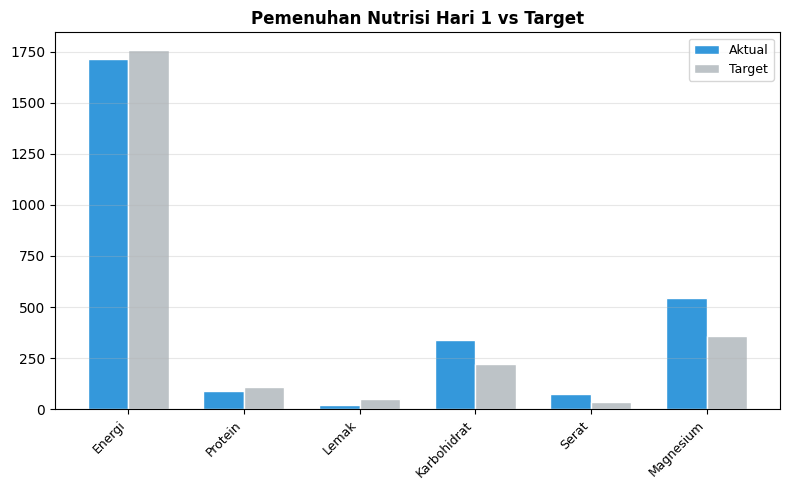

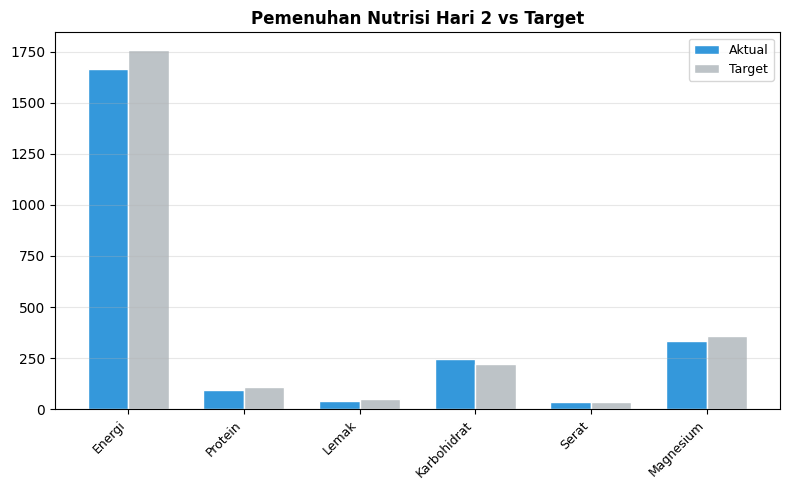

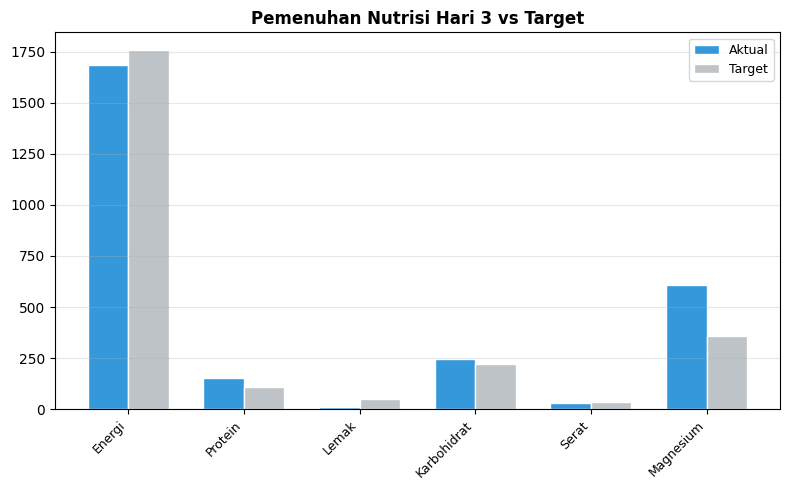

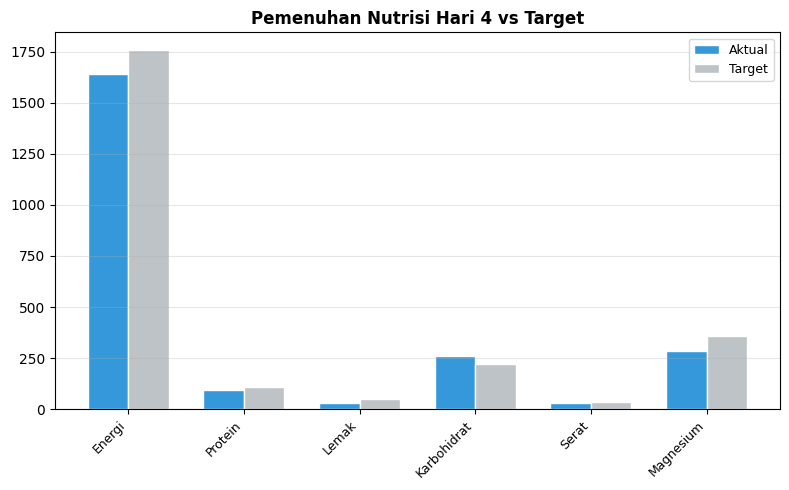

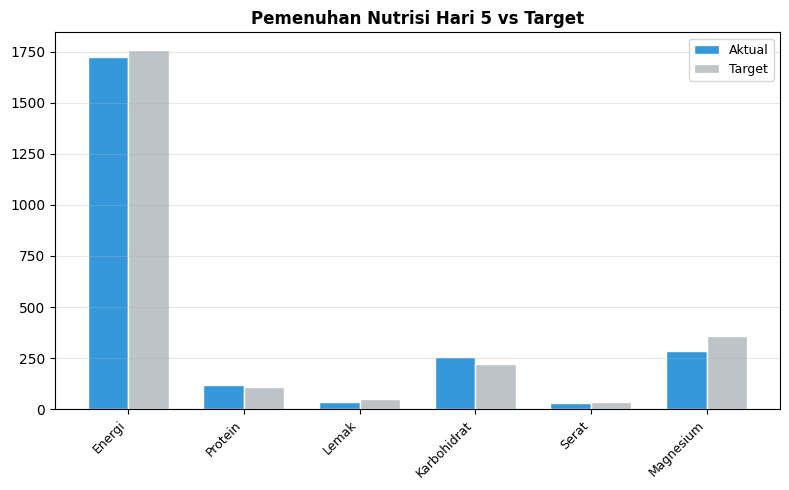

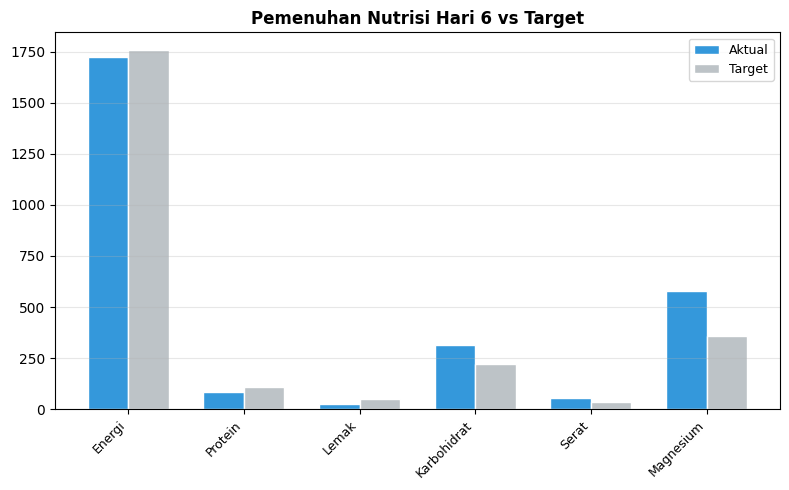

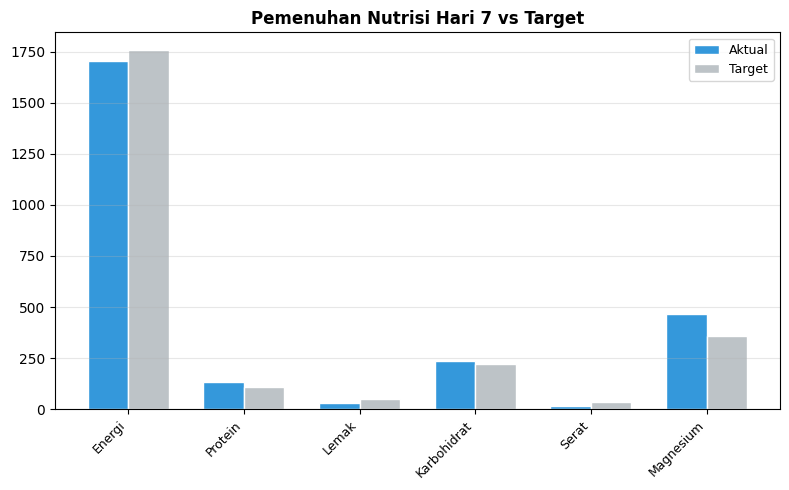


    EVALUASI MEAL PLAN
  Target Kalori Harian    : 1757 kkal

  MAPE per Nutrisi (% dari target):
    Energi         : 3.6%
    Protein        : 18.4%
    Lemak          : 45.0%
    Karbohidrat    : 23.5%
    Serat          : 39.4%
    Kalium         : 13.1%
    Kalsium        : 32.7%
    Magnesium      : 36.9%
    Besi           : 178.5%
    VitaminC       : 93.4%
    VitaminD       : 82.0%

  Rata-rata MAPE       : 51.5%

  Detail kalori per hari:
    Hari 1: 1715 kkal (selisih -42 kkal / -2.4%) ✓
    Hari 2: 1663 kkal (selisih -94 kkal / -5.3%) ✓
    Hari 3: 1684 kkal (selisih -73 kkal / -4.1%) ✓
    Hari 4: 1641 kkal (selisih -116 kkal / -6.6%) ✓
    Hari 5: 1725 kkal (selisih -32 kkal / -1.8%) ✓
    Hari 6: 1726 kkal (selisih -31 kkal / -1.8%) ✓
    Hari 7: 1702 kkal (selisih -55 kkal / -3.1%) ✓


In [133]:
def main():
    # Memproses data pengguna
    gender          = 'laki-laki'
    age             = 40
    height          = 175
    weight          = 110
    activity_level  = 'sedentary'
    target_weight   = 90
    duration_months = 8.0

    user_input = process_user_data(
        gender          = gender,
        age             = age,
        height          = height,
        weight          = weight,
        activity_level  = activity_level,
        target_weight   = target_weight,
        duration_months = duration_months
    )

    if not user_input['is_valid']:
        for w in user_input['warnings']:
            print(f"  - {w}")
        if user_input['suggestion']:
            print(f"  Saran: {user_input['suggestion']}")
        return

    nutrition_req = user_input['nutrition_req']

    # Tampilkan informasi pengguna
    display_user_info(user_input, nutrition_req)

    # Generate meal plan KNN + Knapsack 0/1
    meal_plan = generate_meal_plan( 
        nutrition_req   = nutrition_req,
        df_preprocessed = df_preprocessed,
        df_original     = df_original,
        scaler          = scaler,
        nutrient_cols   = nutrient_cols,
        days            = 7
    )

    # Tampilkan rekomendasi makanan
    display_meal_plan(meal_plan, nutrition_req)

    # Export ke CSV
    meal_plan_df = export_meal_plan_to_df(meal_plan)

    # Evaluasi meal plan
    comparison = visualize_nutrition_comparison(meal_plan_df, nutrition_req)
    
    evaluate_meal_plan(meal_plan_df, nutrition_req, nutrition_req['Energi'])


if __name__ == "__main__":
    main()